# Experimentos con Covariables v6 GARCH (Vertex AI) — bloque C-D

**Tesis MEC** — variante focalizada del bloque **C-D** (ARIMAX-GARCH) del notebook
`experimentos_covariables_v6_cloud.ipynb`. Agrega un benchmark clásico que sí modela la
volatilidad condicional (`ARIMAXGARCHModel` = `arch.arch_model(mean='ARX', vol='GARCH')`)
junto al `SARIMAX(1,0,0) con X` homoscedástico ya existente.

**Motivación.** En el notebook original el único clásico es SARIMAX homoscedástico, lo que
genera una asimetría deliberada con el experimento univariado análogo 3.2.4 (`D.4`) donde
el benchmark sí es AR(1)+GARCH. Este notebook levanta ese pendiente — ver
[`docs/benchmark_garch_covariables_pendiente.md`](../docs/benchmark_garch_covariables_pendiente.md).

**Qué corre.** 5 experimentos × 3 valores de T × R=500 = 15 CSVs en
`results/covariate_v6_garch_vertexai/`. No pisa los CSVs del v6_cloud original
(`results/covariate_v6_vertexai/`).

**Modelos por experimento (3):**
1. `SARIMAX(1,0,0) con X` — clásico homoscedástico (idéntico al v6_cloud, mantiene el contraste).
2. `AR(1)+GARCH(1,1) con X` — **nuevo** benchmark heteroscedástico.
3. `Chronos-2 (con X)` — modelo de fundación.

El nuevo modelo está bien especificado en la **media** (`ARX` con `X_t`) y misespecificado en
la **varianza** (la librería `arch` no soporta `delta_var·X_t^2` en la ecuación de varianza;
solo capta heteroscedasticidad endógena vía rezagos). Es un contraste más exigente que el
SARIMAX puro, aceptando la limitación conocida.

**Métricas, CRPS y seed (`SEED=3649`):** idénticos al v6_cloud → trayectorias reproducibles
para los tres modelos.


In [1]:
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")

import copy
import logging
import sys
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import torch
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.vector_ar.var_model import VAR as SMVAR

from mectesis.dgp import (
    ARIMAX_DGP, ARIMAX2Cov_DGP, ARIMAX_GARCH_DGP,
    ARIMAX_TREND_DGP, SARIMAX_SEASONAL_DGP,
    VARX_DGP, ADL_ECM_DGP,
)
from mectesis.models import (
    SARIMAXModel, VARMAXModel, ARDLModel,
    ARIMAXGARCHModel,
    ChronosModel, ChronosCovariateModel,
    ChronosMultivariateCovariateModel,
)
from mectesis.simulation import (
    CovariateMonteCarloEngine, CovariateMultivariateEngine,
)

# ── Parametros globales (identicos a v5_cloud -> resultados comparables) ──────
SEED    = 3649
H_BY_T  = {50: 6, 100: 18, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [50, 100, 200]
RESULTS = Path("results/covariate_v6_garch_vertexai")
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Logging dual: notebook + archivo .log ────────────────────────────────────
log_path = RESULTS / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger().info
log(f"Log en: {log_path}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

# ── Chronos-2: cargar una sola vez y envolver para univariado/multivariado ──
device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Cargando Chronos-2 en {device} (puede tardar ~30 s la primera vez)...")
_chronos_base   = ChronosModel(device=device)
chronos_cov1    = ChronosCovariateModel(_chronos_base, n_covariates=1)
chronos_cov2    = ChronosCovariateModel(_chronos_base, n_covariates=2,
                       cov_names=["x0", "x1"])
chronos_mv_cov1 = ChronosMultivariateCovariateModel(_chronos_base, n_covariates=1)
log("Chronos-2 listo.")


19:22:33  Log en: results\covariate_v6_garch_vertexai\run_20260528_192233.log
19:22:33  Cargando Chronos-2 en cpu (puede tardar ~30 s la primera vez)...
19:23:05  Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares ───────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


# ── Univariate save / load ──────────────────────────────────────────────────

def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, "model", mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns="model").reset_index(drop=True)
        for mname, grp in df.groupby("model", sort=False)
    }


def run_exp_cov(dgp, make_models_fn, dgp_params, exp_id,
                T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Univariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: DataFrame}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


# ── Multivariate save / load ────────────────────────────────────────────────

def _save_results_mv(results: dict, path: Path):
    frames = []
    for mname, var_dict in results.items():
        for var_idx, df in var_dict.items():
            tmp = df.copy()
            tmp.insert(0, "var", var_idx)
            tmp.insert(0, "model", mname)
            frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results_mv(path: Path) -> dict:
    df = pd.read_csv(path)
    results = {}
    for mname, mgrp in df.groupby("model", sort=False):
        results[mname] = {}
        for var_idx, vgrp in mgrp.groupby("var", sort=True):
            results[mname][int(var_idx)] = (
                vgrp.drop(columns=["model", "var"]).reset_index(drop=True)
            )
    return results


def run_exp_mv_cov(dgp, make_models_fn, dgp_params, exp_id,
                    T_list=None, R_list=None, H_by_T=None, seed=SEED):
    """Multivariado con covariables: barre (T, R), cachea CSVs, retorna
    {(T, R): {model_name: {var_idx: DataFrame}}}."""
    T_list = T_list if T_list is not None else T_LIST
    R_list = R_list if R_list is not None else R_LIST
    H_by_T = H_by_T if H_by_T is not None else H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")

    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results_mv(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models  = make_models_fn(T)
            engine  = CovariateMultivariateEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results_mv(results, cache)
            all_results[(T, R)] = results
    return all_results


# ─── Bloques v3 (Corto / Medio / Largo) ─────────────────────────────────────

BLOCK_DEFS  = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3  = ["bias", "variance", "rmse", "crps"]


def compute_blocks_v3(results_TR: dict) -> dict:
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        blks = {}
        for blk, h1, h2 in BLOCK_DEFS:
            mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
            blks[blk] = df_h[mask].mean(numeric_only=True)
        out[mname] = blks
    return out


def build_grid_table(all_results: dict, classical_name: str,
                     chronos_name: str = "Chronos-2 (con X)"):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_v3(res_TR)
        cl_blks  = blk_data.get(classical_name, {})
        ch_blks  = blk_data.get(chronos_name, {})

        for mname, blks in blk_data.items():
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = blks.get(blk, pd.Series(dtype=float))
                for m in METRICS_V3:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["rmse", "crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def compute_blocks_mv(results_TR: dict) -> dict:
    out = {}
    for mname, var_dict in results_TR.items():
        out[mname] = {}
        for var_idx, df in var_dict.items():
            df_h = df[df["horizon"] != "avg_all"].copy()
            df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
            blks = {}
            for blk, h1, h2 in BLOCK_DEFS:
                mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
                blks[blk] = df_h[mask].mean(numeric_only=True)
            out[mname][var_idx] = blks
    return out


def build_grid_table_mv(all_results, classical_name: str,
                         chronos_name: str = "Chronos-2 joint (con X)",
                         var_names=None):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        var_idx_set = set()
        for var_dict in blk_data.values():
            var_idx_set.update(var_dict.keys())
        var_idx_set = {v for v in var_idx_set if v >= 0}   # excluir joint

        for var_idx in sorted(var_idx_set):
            vname = var_names[var_idx] if var_names else f"Y{var_idx+1}"
            cl_blks = blk_data.get(classical_name, {}).get(var_idx, {})
            ch_blks = blk_data.get(chronos_name, {}).get(var_idx, {})

            for mname, var_blks in blk_data.items():
                if var_idx not in var_blks:
                    continue
                blks = var_blks[var_idx]
                row = {"T": T, "Variable": vname, "Modelo": mname}
                for blk, h1, h2 in BLOCK_DEFS:
                    s = blks.get(blk, pd.Series(dtype=float))
                    for m in METRICS_V3:
                        row[f"{m}_{blk}"] = (
                            round(float(s[m]), 4)
                            if m in s.index and pd.notna(s[m]) else np.nan
                        )
                    cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                    ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                    for m in ["rmse", "crps"]:
                        cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                        hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                        if np.isnan(cv) or np.isnan(hv):
                            row[f"best_{m}_{blk}"] = np.nan
                        else:
                            row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
                rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Variable", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def build_grid_table_mv_joint(all_results, classical_name: str,
                               chronos_name: str = "Chronos-2 joint (con X)"):
    """Tabla 2 (multivariada conjunta) por (T, Modelo) con Trace MSFE y avgCRPS.
    Lee la fila virtual var=-1 que inyecta el engine (si esta presente)."""
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_mv(res_TR)
        cl_blks = blk_data.get(classical_name, {}).get(-1, {})
        ch_blks = blk_data.get(chronos_name, {}).get(-1, {})

        for mname, var_blks in blk_data.items():
            joint = var_blks.get(-1, None)
            if joint is None:
                continue
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = joint.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["trace_msfe", "avg_crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    if not rows:
        log("  [tabla joint] sin filas — el CSV no contiene metricas joint "
            "(probablemente el engine no inyecta var=-1; ignorar).")
        return

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


# ─── Visualizacion de simulacion representativa ─────────────────────────────

def plot_simulation_cov(dgp, models, dgp_params, title="", T_vis=100, seed=SEED):
    """Visualiza una realizacion univariada: historico + test + forecasts + intervalos
    para cada modelo (con o sin covariables)."""
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(seed + 99991)
    data = dgp_copy.simulate(T=T_vis, **dgp_params)
    y, X = data["y"], data["X"]
    y_train, y_test = y[:-H_vis], y[-H_vis:]
    X_train, X_future = X[:-H_vis], X[-H_vis:]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    t_train = np.arange(len(y_train))
    t_test  = np.arange(len(y_train), T_vis)
    ax.plot(t_train, y_train, color="gray", lw=1.5, label="Historico")
    ax.axvline(len(y_train) - 0.5, color="black", ls="--", lw=1, alpha=0.6)
    ax.plot(t_test, y_test, color="black", lw=1.5, marker="o", ms=3, label="Observado")

    palette = ["steelblue", "darkorange", "seagreen", "purple", "teal", "crimson"]
    for i, model in enumerate(models):
        try:
            fkw = {"X_train": X_train} if getattr(model, "supports_covariates", False) else {}
            model.fit(y_train, **fkw)
            pkw = {"X_future": X_future} if getattr(model, "supports_covariates", False) else {}
            fcst = model.forecast(H_vis, **pkw)
            c = palette[i % len(palette)]
            ax.plot(t_test, fcst, color=c, lw=1.5, ls="--", marker="s", ms=3,
                    label=model.name)
            if getattr(model, "supports_intervals", False):
                lo, hi = model.forecast_intervals(H_vis, level=0.80, **pkw)
                ax.fill_between(t_test, lo, hi, color=c, alpha=0.15)
        except Exception as e:
            log(f"  [plot] {model.name} fallo: {e}")

    ax.set(title=title, xlabel="t", ylabel="y")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_simulation_mv_cov(dgp, models, dgp_params, var_names=None,
                            title="", T_vis=100, seed=SEED):
    """Visualizacion multivariada: k subplots verticales con historico + test +
    forecasts + intervalos para cada modelo y cada variable."""
    H_vis = H_BY_T.get(T_vis, H_MAX)
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(seed + 99991)
    data = dgp_copy.simulate(T=T_vis, **dgp_params)
    Y, X = data["y"], data["X"]
    k = Y.shape[1]
    y_train, y_test = Y[:-H_vis], Y[-H_vis:]
    X_train, X_future = X[:-H_vis], X[-H_vis:]

    for m in models:
        try:
            fkw = {"X_train": X_train} if getattr(m, "supports_covariates", False) else {}
            m.fit(y_train, **fkw)
        except Exception as e:
            log(f"  [plot] {m.name} fit fallo: {e}")

    palette = ["steelblue", "darkorange", "seagreen", "purple", "teal", "crimson"]
    fig, axes = plt.subplots(k, 1, figsize=(11, 3.0 * k), squeeze=False)
    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T_vis)

    for j, ax in enumerate(axes[:, 0]):
        vname = var_names[j] if var_names else f"Y{j+1}"
        ax.plot(x_tr, y_train[:, j], color="gray", lw=1.4, alpha=0.85, label="Historico")
        ax.plot(x_te, y_test[:, j], "k--", lw=1.5, label="Observado (test)")
        ax.axvline(len(y_train) - 0.5, color="black", ls="--", lw=1, alpha=0.5)

        for i, m in enumerate(models):
            try:
                pkw = {"X_future": X_future} if getattr(m, "supports_covariates", False) else {}
                y_hat = m.forecast(H_vis, **pkw)
                c = palette[i % len(palette)]
                ax.plot(x_te, y_hat[:, j], color=c, lw=1.5, ls="--",
                        marker="s", ms=3, label=m.name)
                if getattr(m, "supports_intervals", False):
                    lo, hi = m.forecast_intervals(H_vis, level=0.80, **pkw)
                    ax.fill_between(x_te, lo[:, j], hi[:, j], color=c, alpha=0.12)
            except Exception as e:
                log(f"  [plot] {m.name} forecast fallo en var {j}: {e}")

        ax.set(title=f"{vname}", xlabel="t", ylabel=vname)
        ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ─── Verificacion DGP con covariables ───────────────────────────────────────

def verify_dgp_cov(label, dgp, dgp_params, checks):
    """Replica el patron `verify_dgp` de v4_cloud para DGPs univariados con
    covariables. Cada check recibe (y, X, dgp, dgp_params)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=1000, **dgp_params)
        y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


def verify_dgp_mv_cov(label, dgp, dgp_params, checks):
    """Version multivariada: y es (T, k), X es (T, p)."""
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        data = dgp_copy.simulate(T=500, **dgp_params)
        Y, X = data["y"], data["X"]
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(Y, X, dgp, dgp_params)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


# ── Checks individuales (univariados con covariables) ───────────────────────

def chk_y_stationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval < 0.05, f"ADF Y p={pval:.4f} (umbral 0.05)"


def chk_y_nonstationary(y, X, dgp, params):
    pval = adfuller(y, autolag="AIC")[1]
    return pval > 0.10, f"ADF Y p={pval:.4f} (se espera >0.10)"


def chk_y_zero_mean(y, X, dgp, params):
    """Media de Y ~ 0 usando standard error robusto a autocorrelacion
    (Newey-West / Bartlett kernel). El SE tipico sigma/sqrt(T) subestima
    la varianza de la media muestral cuando Y es persistente — caso
    tipico de ARIMAX con phi alto y/o rho_x alto. Si el DGP tiene
    componente estacional con periodo s, ampliamos bw a max(bw_default,
    2*s) para capturar las autocovarianzas a lags estacionales — el
    default floor(4*(T/100)^(2/9)) subestima LRV cuando rho[s] es alta."""
    mu = y.mean(); T = len(y)
    e = y - mu
    bw_default = max(1, int(np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0))))
    s = int(params.get("s", 0))
    bw = max(bw_default, 2 * s) if s > 0 else bw_default
    gamma0 = float(np.dot(e, e) / T)
    lrv = gamma0
    for k in range(1, bw + 1):
        w = 1.0 - k / (bw + 1.0)
        gamma_k = float(np.dot(e[k:], e[:-k]) / T)
        lrv += 2.0 * w * gamma_k
    se = np.sqrt(max(lrv, 1e-12) / T)
    tol = 3.0 * se
    tag = f", adaptado a s={s}" if s > 0 else ""
    return abs(mu) < tol, f"media={mu:.4f}, tol=+/-{tol:.4f} (HAC bw={bw}{tag})"


def chk_x_stationary(y, X, dgp, params):
    """Cada columna de X debe ser estacionaria (excepto cuando rho_x es 1, p.ej. ADL-ECM)."""
    pvals = [float(adfuller(X[:, i], autolag="AIC")[1]) for i in range(X.shape[1])]
    ok = all(p < 0.05 for p in pvals)
    return ok, f"ADF X p-vals={[round(p, 4) for p in pvals]}"


def chk_x_nonstationary(y, X, dgp, params):
    """X debe ser I(1) — ADF en niveles no rechaza, ADF en diferencias rechaza."""
    msgs, ok_all = [], True
    for i in range(X.shape[1]):
        pv_lvl = float(adfuller(X[:, i], autolag="AIC")[1])
        pv_dif = float(adfuller(np.diff(X[:, i]), autolag="AIC")[1])
        ok_i = (pv_lvl > 0.10) and (pv_dif < 0.05)
        ok_all = ok_all and ok_i
        msgs.append(f"X{i}: lvl={pv_lvl:.3f}, dif={pv_dif:.3f}")
    return ok_all, " | ".join(msgs)


def chk_acf_rho_x(y, X, dgp, params):
    rho = params.get("rho_x", None)
    if rho is None:
        return True, "no aplica (sin rho_x)"
    empirics = []
    for i in range(X.shape[1]):
        emp = float(acf(X[:, i], nlags=1, fft=True)[1])
        empirics.append(emp)
    diffs = [abs(e - rho) for e in empirics]
    ok = all(d < 0.15 for d in diffs)
    return ok, f"ACF[1] X={[round(e, 3) for e in empirics]}, rho_x_DGP={rho}"


def chk_yx_correlation(y, X, dgp, params):
    """Correlacion contemporanea no nula y con signo correcto cuando el efecto
    exogeno en la media no es cero. Si el DGP tiene tendencia deterministica
    (delta != 0), la varianza total de Y queda dominada por delta*t y la
    correlacion contemporanea queda diluida — en ese caso detrend Y primero
    via OLS lineal para aislar la senal estocastica."""
    for key in ("beta", "beta_mean", "beta1"):
        if key in params and params[key] != 0:
            val = params[key]
            y_used = y
            tag = ""
            if params.get("delta", 0.0) != 0.0:
                T = len(y)
                t = np.arange(T)
                slope, intercept = np.polyfit(t, y, 1)
                y_used = y - (slope * t + intercept)
                tag = "_detrended"
            corr = float(np.corrcoef(y_used, X[:, 0])[0, 1])
            ok = (abs(corr) > 0.05) and (np.sign(corr) == np.sign(val))
            return ok, f"corr(Y{tag},X[0])={corr:.4f}, {key}={val}"
    return True, "no aplica (efecto exogeno en media = 0)"


def chk_arch_effects_resid(y, X, dgp, params):
    """Detecta efectos ARCH en residuos de una regresion OLS de Y sobre X (proxy)."""
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    lb = acorr_ljungbox(resid ** 2, lags=[10], return_df=True)
    pval = float(lb["lb_pvalue"].iloc[0])
    return pval < 0.05, f"LB(10) sobre resid^2: p={pval:.4f} (se espera <0.05)"


def chk_fit_sarimax(y, X, dgp, params):
    """Smoke test: SARIMAX con covariables ajusta y forecastea sin NaN."""
    try:
        m = SARIMAXModel((1, 0, 0), name_suffix="check")
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"SARIMAX fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Checks individuales (multivariados con covariables, k=2) ────────────────

def chk_varx_stability(Y, X, dgp, params):
    A = np.asarray(getattr(dgp, "A"))
    eig = np.linalg.eigvals(A)
    mod_max = float(np.max(np.abs(eig)))
    return mod_max < 0.999, f"max|lambda(A)|={mod_max:.4f} (umbral 0.999)"


def chk_sigma_psd_mv(Y, X, dgp, params):
    Sigma = np.asarray(getattr(dgp, "Sigma"))
    try:
        np.linalg.cholesky(Sigma)
    except np.linalg.LinAlgError as e:
        return False, f"Sigma no es PSD: {e}"
    eigs = np.linalg.eigvalsh(Sigma)
    return float(eigs.min()) > 1e-8, f"min eig(Sigma)={float(eigs.min()):.6f}"


def chk_x_stationary_mv(Y, X, dgp, params):
    rho = getattr(dgp, "rho_x", None)
    pval = float(adfuller(X[:, 0], autolag="AIC")[1])
    msg = f"ADF X p={pval:.4f}" + (f", rho_x_DGP={rho}" if rho is not None else "")
    return pval < 0.05, msg


def chk_empirical_finite_mv(Y, X, dgp, params):
    if not (np.all(np.isfinite(Y)) and np.all(np.isfinite(X))):
        return False, "Y o X contiene NaN/inf"
    sd_y = np.std(Y, axis=0)
    return bool(np.all(sd_y < 1e6)), f"std(Y)={np.round(sd_y, 3).tolist()}"


def chk_varx_gamma_signal(Y, X, dgp, params):
    """Si gamma!=0, la correlacion Y_i ~ X[0] debe tener signo correcto."""
    gamma = np.asarray(getattr(dgp, "gamma", [0.0, 0.0]))
    msgs, ok_all = [], True
    for i in range(Y.shape[1]):
        if gamma[i] == 0:
            msgs.append(f"Y{i+1}: no aplica (gamma=0)")
            continue
        corr = float(np.corrcoef(Y[:, i], X[:, 0])[0, 1])
        ok_i = (abs(corr) > 0.03) and (np.sign(corr) == np.sign(gamma[i]))
        ok_all = ok_all and ok_i
        msgs.append(f"Y{i+1}: corr={corr:.3f}, gamma={gamma[i]}")
    return ok_all, " | ".join(msgs)


# ── Checks ADL-ECM (cointegracion) ──────────────────────────────────────────

def chk_y_I1(y, X, dgp, params):
    pv_lvl = float(adfuller(y, autolag="AIC")[1])
    pv_dif = float(adfuller(np.diff(y), autolag="AIC")[1])
    ok = (pv_lvl > 0.10) and (pv_dif < 0.05)
    return ok, f"ADF Y lvl={pv_lvl:.3f}, dif={pv_dif:.3f}"


def chk_cointegration_yx(y, X, dgp, params):
    """La combinacion lineal Y - X debe ser I(0)."""
    z = y - X[:, 0]
    pv = float(adfuller(z, autolag="AIC")[1])
    return pv < 0.05, f"ADF(Y-X) p={pv:.4f} (se espera <0.05)"


def chk_fit_ardl(y, X, dgp, params):
    try:
        m = ARDLModel()
        m.fit(y[:800], X_train=X[:800])
        fc = m.forecast(horizon=6, X_future=X[800:806])
        ok = (len(fc) == 6) and (not np.any(np.isnan(fc)))
        return ok, f"ARDL-ECM fit+forecast OK, primeros: {np.round(fc[:3], 4)}"
    except Exception as e:
        return False, str(e)


# ── Grupos de checks por familia de DGP ─────────────────────────────────────

CHECKS_ARIMAX = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX(1,0,0) con X fit+forecast",     chk_fit_sarimax),
]

CHECKS_ARIMAX_GARCH = [
    ("Y estacionaria en media (ADF)",         chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Efectos ARCH detectables en residuos",  chk_arch_effects_resid),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]

CHECKS_VARX = [
    ("Estabilidad VAR (max|eig(A)|<1)",       chk_varx_stability),
    ("Sigma PSD",                             chk_sigma_psd_mv),
    ("X estacionaria (ADF)",                  chk_x_stationary_mv),
    ("Salida finita y std razonable",         chk_empirical_finite_mv),
    ("Senal de gamma en Y",                   chk_varx_gamma_signal),
]

CHECKS_ADL_ECM = [
    ("Y es I(1) (ADF niveles/diferencias)",   chk_y_I1),
    ("X es I(1) (ADF niveles/diferencias)",   chk_x_nonstationary),
    ("Y - X es I(0) (cointegracion)",         chk_cointegration_yx),
    ("ARDL-ECM fit+forecast",                 chk_fit_ardl),
]


# ── Checks tendencia / estacionalidad ───────────────────────────────────────

def chk_trend_slope(y, X, dgp, params):
    """OLS slope de Y vs t cercana a delta. Con T=1000 y delta=0.05, la
    desviacion tipica del estimador es ~sigma_y * sqrt(12)/T^{1.5} ~ 0.0001
    para sigma_y=1 y T=1000, asi que tol=0.01 es comodo y conservador."""
    delta = params.get("delta", None)
    if delta is None:
        return True, "no aplica"
    T = len(y)
    slope = float(np.polyfit(np.arange(T), y, 1)[0])
    tol = max(0.01, 0.20 * abs(delta))
    return abs(slope - delta) < tol, f"slope_OLS={slope:.5f}, delta_DGP={delta:.5f}, tol={tol:.4f}"


def chk_seasonal_acf(y, X, dgp, params):
    """ACF[s] de los residuos OLS de Y sobre X significativamente positiva.
    Se quita el efecto exogeno aproximadamente regresando Y sobre X para
    aislar la senal estacional."""
    s = params.get("s", 4)
    X_with_const = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X_with_const, y, rcond=None)
    resid = y - X_with_const @ coef
    T = len(resid)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(resid, nlags=s + 1, fft=True)
    val_s = abs(acf_vals[s])
    return val_s > thr, f"|ACF[s={s}](resid)|={val_s:.4f}, umbral 2/sqrt(T)={thr:.4f}"


CHECKS_ARIMAX_TREND = [
    ("Y tendencia: slope_OLS ~ delta",        chk_trend_slope),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[1] de X ~ rho_x",                   chk_acf_rho_x),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X+trend fit+forecast",      chk_fit_sarimax),
]

CHECKS_ARIMAX_SEASONAL = [
    ("Y estacionaria (ADF)",                  chk_y_stationary),
    ("Y media ~ 0",                           chk_y_zero_mean),
    ("X estacionaria (ADF)",                  chk_x_stationary),
    ("ACF[s] estacional significativa",       chk_seasonal_acf),
    ("Correlacion Y vs X consistente",        chk_yx_correlation),
    ("SARIMAX con X fit+forecast",            chk_fit_sarimax),
]


---
## Bloque C-D — ARIMAX con volatilidad condicional (5 exps)

La covariable entra en la media y/o en la varianza condicional del error.

**DGP:** $Y_t = 0.4\,Y_{t-1} + \beta_{\text{mean}}\,X_t + \varepsilon_t$,
con $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2
+ \beta_{\text{garch}}\,\sigma_{t-1}^2 + \delta_{\text{var}}\,X_t^2$
y $X_t = 0.7\,X_{t-1} + \eta_t$.

Variantes:
- **C-D.1**: efecto solo en la media ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0$).
- **C-D.2**: efecto en media y varianza ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.1$).
- **C-D.3**: efecto solo en varianza ($\beta_{\text{mean}} = 0$, $\delta_{\text{var}} = 0.3$).
- **C-D.4**: canal de varianza fuerte ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.5$) —
  la covariable domina la heteroscedasticidad ademas de la media.
- **C-D.5**: GARCH persistente ($\alpha = 0.2$, $\beta_{\text{garch}} = 0.7$, $\delta_{\text{var}} = 0.1$) —
  volatilidad mas inercial; mayor exigencia de calibracion de intervalos.

SARIMAX no modela la varianza condicional explicitamente — pierde calibracion
en intervalos cuando $\delta_{\text{var}} > 0$. Aqui se mide si Chronos
absorbe esa estructura implicitamente.


### C-D.1 — ARIMAX-GARCH: efecto solo en la media (delta_var = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0.5\,X_t + \varepsilon_t$, $\sigma_t^2 = 0.1 + 0.1\varepsilon_{t-1}^2 + 0.75\sigma_{t-1}^2$.

**Hipotesis:** GARCH puro sin influencia exogena en la varianza. SARIMAX no modela $\sigma_t$ y tendra intervalos mal calibrados; Chronos quantilico puede capturar la heteroscedasticidad implicitamente.


19:23:05  ────────────────────────────────────────────────────────────
19:23:05  VERIFICACION DGP: C-D.1 -- ARIMAX-GARCH solo media
19:23:05  ────────────────────────────────────────────────────────────
19:23:05    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
19:23:05    [PASS] Y media ~ 0: media=-0.0805, tol=+/-0.2291 (HAC bw=6)
19:23:05    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
19:23:05    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
19:23:05    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
19:23:06    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3701 -0.4409 -0.2161]
19:23:06    -> TODAS LAS VERIFICACIONES PASARON
19:23:06  Exp C-D.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:23:06    T=50 H=6, R=500: simulando...
19:28:42    T=50 H=6, R=500: OK (337s)
19:28:42    T=100 H=18, R=500: simulando...
19:35:02    T=100 H=18, 

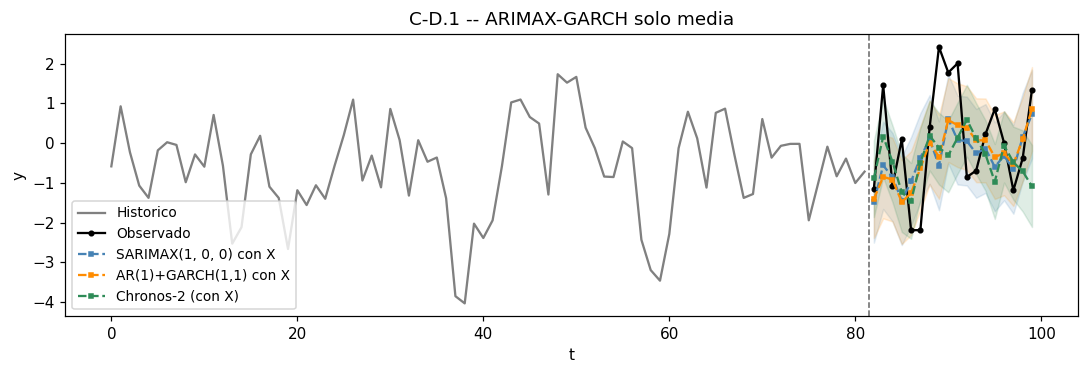

In [3]:
try:
    # C-D.1 -- ARIMAX-GARCH solo media
    dgp_C_D_1 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_1 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_1 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.0, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.1 -- ARIMAX-GARCH solo media", dgp_C_D_1,
                   dgp_params_C_D_1, CHECKS_ARIMAX_GARCH)
    res_C_D_1 = run_exp_cov(
        dgp_C_D_1, make_models_C_D_1, dgp_params_C_D_1,
        exp_id="C-D.1",
    )
    log("\n" + "="*60 + "\nC-D.1 -- ARIMAX-GARCH solo media\n" + "="*60)
    build_grid_table(res_C_D_1, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_1, make_models_C_D_1(200),
                        dgp_params_C_D_1,
                        title="C-D.1 -- ARIMAX-GARCH solo media")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.2 — ARIMAX-GARCH: media + varianza (delta_var = 0.1)

**DGP:** misma estructura, con $X_t^2$ inyectado en la varianza ($\delta_{\text{var}} = 0.1$).

**Hipotesis:** caso completo (replica Exp 3.5). La covariable contribuye a ambos momentos; SARIMAX solo captura el primero.


19:41:39  ────────────────────────────────────────────────────────────
19:41:39  VERIFICACION DGP: C-D.2 -- ARIMAX-GARCH media+var
19:41:39  ────────────────────────────────────────────────────────────
19:41:40    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
19:41:40    [PASS] Y media ~ 0: media=-0.1007, tol=+/-0.2836 (HAC bw=6)
19:41:40    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
19:41:40    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
19:41:40    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
19:41:40    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3736 -0.4596 -0.2363]
19:41:40    -> TODAS LAS VERIFICACIONES PASARON
19:41:40  Exp C-D.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:41:40    T=50 H=6, R=500: simulando...
19:46:15    T=50 H=6, R=500: OK (275s)
19:46:15    T=100 H=18, R=500: simulando...
19:51:26    T=100 H=18, R

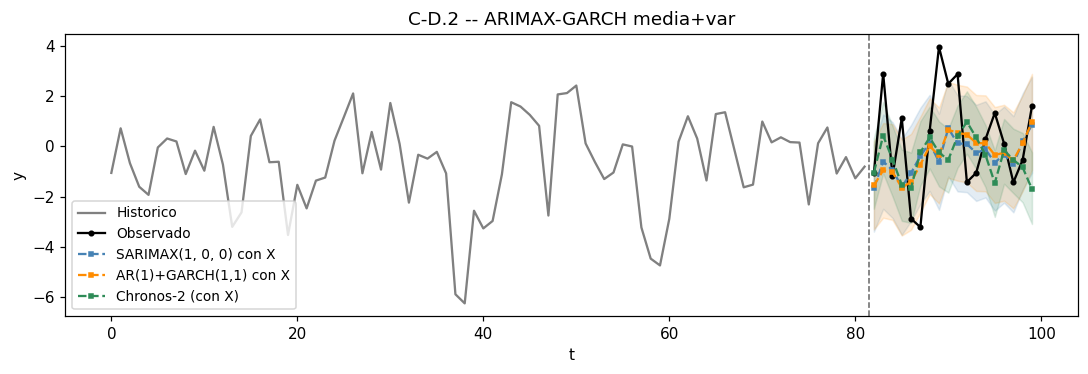

In [4]:
try:
    # C-D.2 -- ARIMAX-GARCH media+var
    dgp_C_D_2 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_2 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_2 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.1, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.2 -- ARIMAX-GARCH media+var", dgp_C_D_2,
                   dgp_params_C_D_2, CHECKS_ARIMAX_GARCH)
    res_C_D_2 = run_exp_cov(
        dgp_C_D_2, make_models_C_D_2, dgp_params_C_D_2,
        exp_id="C-D.2",
    )
    log("\n" + "="*60 + "\nC-D.2 -- ARIMAX-GARCH media+var\n" + "="*60)
    build_grid_table(res_C_D_2, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_2, make_models_C_D_2(200),
                        dgp_params_C_D_2,
                        title="C-D.2 -- ARIMAX-GARCH media+var")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.3 — ARIMAX-GARCH: efecto solo en la varianza (beta_mean = 0)

**DGP:** $Y_t = 0.4\,Y_{t-1} + 0\cdot X_t + \varepsilon_t$, varianza con $\delta_{\text{var}} = 0.3$.

**Hipotesis:** la covariable no informa el nivel pero si la volatilidad. SARIMAX la incluye en la media y el coef estimado deberia ir a cero. Chronos debe identificar el canal de varianza para mejorar intervalos.


19:57:53  ────────────────────────────────────────────────────────────
19:57:53  VERIFICACION DGP: C-D.3 -- ARIMAX-GARCH solo varianza
19:57:53  ────────────────────────────────────────────────────────────
19:57:53    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
19:57:53    [PASS] Y media ~ 0: media=-0.0461, tol=+/-0.2815 (HAC bw=6)
19:57:53    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
19:57:53    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
19:57:53    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
19:57:54    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.0432 -0.0584 -0.064 ]
19:57:54    -> TODAS LAS VERIFICACIONES PASARON
19:57:54  Exp C-D.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:57:54    T=50 H=6, R=500: simulando...
20:01:59    T=50 H=6, R=500: OK (245s)
20:01:59    T=100 H=18, R=500: simulando...
20:06:51    T=100 H=1

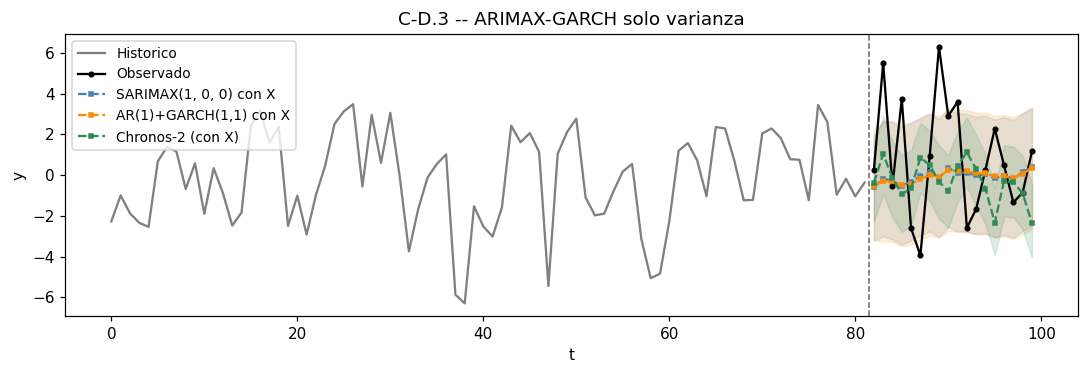

In [5]:
try:
    # C-D.3 -- ARIMAX-GARCH solo varianza
    dgp_C_D_3 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_3 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_3 = dict(phi=0.4, beta_mean=0.0, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.3, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.3 -- ARIMAX-GARCH solo varianza", dgp_C_D_3,
                   dgp_params_C_D_3, CHECKS_ARIMAX_GARCH)
    res_C_D_3 = run_exp_cov(
        dgp_C_D_3, make_models_C_D_3, dgp_params_C_D_3,
        exp_id="C-D.3",
    )
    log("\n" + "="*60 + "\nC-D.3 -- ARIMAX-GARCH solo varianza\n" + "="*60)
    build_grid_table(res_C_D_3, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_3, make_models_C_D_3(200),
                        dgp_params_C_D_3,
                        title="C-D.3 -- ARIMAX-GARCH solo varianza")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.4 — ARIMAX-GARCH: canal de varianza fuerte (delta_var = 0.5)

**DGP:** media con $\beta_{\text{mean}} = 0.5$ y varianza con $\delta_{\text{var}} = 0.5$ ($X_t^2$ inyectado fuerte).

**Hipotesis:** la covariable domina la heteroscedasticidad. SARIMAX pierde calibracion severamente; mide si Chronos quantilico absorbe el canal de varianza para mantener cobertura.


20:12:38  ────────────────────────────────────────────────────────────
20:12:38  VERIFICACION DGP: C-D.4 -- ARIMAX-GARCH var fuerte
20:12:38  ────────────────────────────────────────────────────────────
20:12:38    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
20:12:38    [PASS] Y media ~ 0: media=-0.1357, tol=+/-0.4252 (HAC bw=6)
20:12:38    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
20:12:38    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
20:12:38    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
20:12:38    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.4002 -0.5017 -0.2807]
20:12:38    -> TODAS LAS VERIFICACIONES PASARON
20:12:38  Exp C-D.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
20:12:38    T=50 H=6, R=500: simulando...
20:16:20    T=50 H=6, R=500: OK (222s)
20:16:20    T=100 H=18, R=500: simulando...
20:21:04    T=100 H=18, 

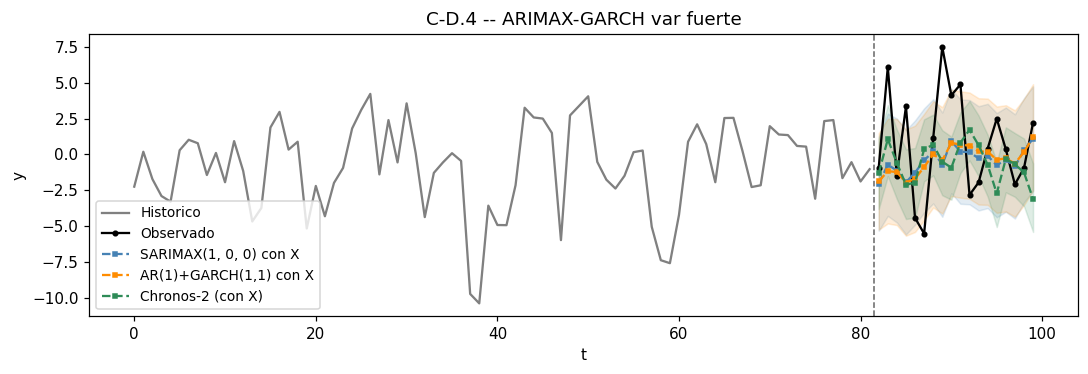

In [6]:
try:
    # C-D.4 -- ARIMAX-GARCH var fuerte
    dgp_C_D_4 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_4 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_4 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.1, beta_garch=0.75, delta_var=0.5, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.4 -- ARIMAX-GARCH var fuerte", dgp_C_D_4,
                   dgp_params_C_D_4, CHECKS_ARIMAX_GARCH)
    res_C_D_4 = run_exp_cov(
        dgp_C_D_4, make_models_C_D_4, dgp_params_C_D_4,
        exp_id="C-D.4",
    )
    log("\n" + "="*60 + "\nC-D.4 -- ARIMAX-GARCH var fuerte\n" + "="*60)
    build_grid_table(res_C_D_4, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_4, make_models_C_D_4(200),
                        dgp_params_C_D_4,
                        title="C-D.4 -- ARIMAX-GARCH var fuerte")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


### C-D.5 — ARIMAX-GARCH persistente (alpha=0.2, beta_garch=0.7)

**DGP:** misma media ($\beta_{\text{mean}} = 0.5$, $\delta_{\text{var}} = 0.1$) con GARCH mas inercial ($\alpha = 0.2$, $\beta_{\text{garch}} = 0.7$).

**Hipotesis:** volatilidad mas persistente (clustering pronunciado). Mayor exigencia de calibracion de intervalos a lo largo del horizonte.


20:27:06  ────────────────────────────────────────────────────────────
20:27:06  VERIFICACION DGP: C-D.5 -- ARIMAX-GARCH persistente
20:27:06  ────────────────────────────────────────────────────────────
20:27:06    [PASS] Y estacionaria en media (ADF): ADF Y p=0.0000 (umbral 0.05)
20:27:06    [PASS] Y media ~ 0: media=-0.1031, tol=+/-0.3006 (HAC bw=6)
20:27:06    [PASS] X estacionaria (ADF): ADF X p-vals=[0.0]
20:27:06    [PASS] ACF[1] de X ~ rho_x: ACF[1] X=[0.697], rho_x_DGP=0.7
20:27:06    [PASS] Efectos ARCH detectables en residuos: LB(10) sobre resid^2: p=0.0000 (se espera <0.05)
20:27:07    [PASS] SARIMAX con X fit+forecast: SARIMAX fit+forecast OK, primeros: [-0.3791 -0.4643 -0.2439]
20:27:07    -> TODAS LAS VERIFICACIONES PASARON
20:27:07  Exp C-D.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
20:27:07    T=50 H=6, R=500: simulando...
20:31:44    T=50 H=6, R=500: OK (277s)
20:31:44    T=100 H=18, R=500: simulando...
20:37:21    T=100 H=18,

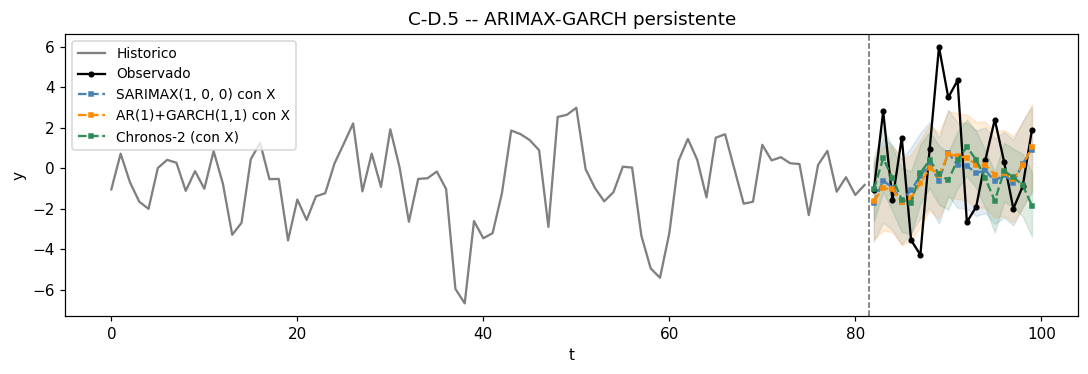

In [7]:
try:
    # C-D.5 -- ARIMAX-GARCH persistente
    dgp_C_D_5 = ARIMAX_GARCH_DGP(seed=SEED)
    make_models_C_D_5 = lambda T: [
        SARIMAXModel((1, 0, 0), name_suffix='con X'),
        ARIMAXGARCHModel(ar_lags=1, p=1, q=1),
        chronos_cov1,
    ]
    dgp_params_C_D_5 = dict(phi=0.4, beta_mean=0.5, omega=0.1, alpha=0.2, beta_garch=0.7, delta_var=0.1, sigma_x=1.0, rho_x=0.7)
    verify_dgp_cov("C-D.5 -- ARIMAX-GARCH persistente", dgp_C_D_5,
                   dgp_params_C_D_5, CHECKS_ARIMAX_GARCH)
    res_C_D_5 = run_exp_cov(
        dgp_C_D_5, make_models_C_D_5, dgp_params_C_D_5,
        exp_id="C-D.5",
    )
    log("\n" + "="*60 + "\nC-D.5 -- ARIMAX-GARCH persistente\n" + "="*60)
    build_grid_table(res_C_D_5, classical_name="SARIMAX(1, 0, 0) con X",
                     chronos_name="Chronos-2 (con X)")
    plot_simulation_cov(dgp_C_D_5, make_models_C_D_5(200),
                        dgp_params_C_D_5,
                        title="C-D.5 -- ARIMAX-GARCH persistente")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C-D.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())


---

## Próximos pasos (post-corrida)

Una vez generados los 15 CSVs en `results/covariate_v6_garch_vertexai/`:

1. **Validar** que cada CSV tiene 3 modelos × `(horizon+1)` filas y que la columna
   `model` contiene `SARIMAX(1, 0, 0) con X`, `AR(1)+GARCH(1,1) con X` y
   `Chronos-2 (con X)`.
2. **Decidir integración con la tesis** (sección 3.4.2):
   - opción simple: copiar los nuevos CSVs sobre
     `results/covariate_v6_vertexai/exp_C-D_*_T*_R500.csv` y regenerar tablas con
     `python scripts/build_thesis_tables.py`;
   - opción path-aware: parametrizar `RESULTS_DIR` en los scripts de tesis para que
     C-D venga de este path y el resto del v6_cloud.
3. **Actualizar el texto de 3.4.2** quitando la justificación del SARIMAX homoscedástico
   y describiendo el nuevo benchmark.
